Topper:
 Name          Maria Shaw
TotalMarks           269
Grade                  B
Name: 8, dtype: object


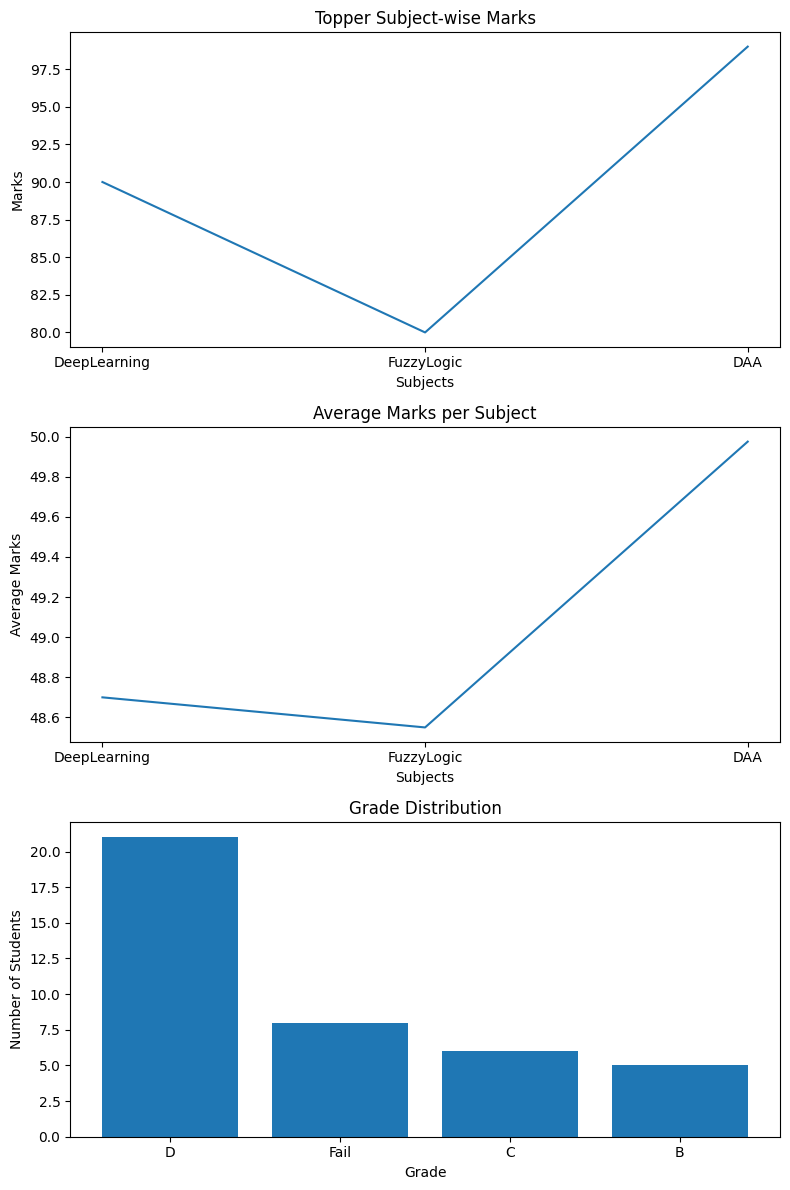

In [3]:
import numpy as np
import pandas as pd
from faker import Faker
import matplotlib.pyplot as plt

fake=Faker()
np.random.seed(42)
students=40

data={'Name':[fake.name() for _ in range(students)],
      'student_id':list(range(1,students+1)),
      'roll_no':np.random.permutation(np.arange(1,students+1)),
      'DeepLearning':np.random.randint(1,101,students),
      'FuzzyLogic':np.random.randint(1,101,students),
      'DAA':np.random.randint(1,101,students)
}

df=pd.DataFrame(data)
# Number of subjects
subjects = ['DeepLearning','FuzzyLogic','DAA']
num_subjects = len(subjects)
max_marks_per_subject = 100

# Total Marks (you already have)
df['TotalMarks'] = df[subjects].sum(axis=1)

# Percentage
df['TotalPercentage'] = (df['TotalMarks'] / (num_subjects * max_marks_per_subject)) * 100

def grade(avg):

    if avg>=90:
        return 'A'
    
    if avg >=75:
         return 'B'
    
    if avg>=60:

        return 'C'
    
    if avg>=35: 
        return 'D'
    
    else:
        return 'Fail'
    


df['Grade']=df['TotalPercentage'].apply(grade)
topper=df.loc[df['TotalPercentage'].idxmax()]

print("Topper:\n", topper[['Name', 'TotalMarks',  'Grade']])

maxsub=df.loc[df['DAA'].idxmax()]
grade_counts = df['Grade'].value_counts()

# Prepare data
topper_marks = topper[subjects]
subject_avg = df[subjects].mean()
grade_counts = df['Grade'].value_counts()

# Create subplots (3 rows, 1 column)
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

# Plot 1: Topper marks
axes[0].plot(subjects, topper_marks)
axes[0].set_title("Topper Subject-wise Marks")
axes[0].set_xlabel("Subjects")
axes[0].set_ylabel("Marks")

# Plot 2: Average marks
axes[1].plot(subjects, subject_avg)
axes[1].set_title("Average Marks per Subject")
axes[1].set_xlabel("Subjects")
axes[1].set_ylabel("Average Marks")

# Plot 3: Grade distribution
axes[2].bar(grade_counts.index, grade_counts.values)
axes[2].set_title("Grade Distribution")
axes[2].set_xlabel("Grade")
axes[2].set_ylabel("Number of Students")

plt.tight_layout()
plt.show()


